### Exploratory Data Analysis

#### Library Imports and Setting Configurations

In [1]:
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.autolayout': True
})

#### Getting the Data

Global variables 

In [3]:
DIR_PATH = Path.cwd().parent 
DATA_PATH = DIR_PATH / 'master_data' / 'pitching_master.csv'

Loading the master_csv and looking at the data! 

In [4]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["age_c", "age_c_sq"], errors="ignore")

In [5]:
df.head() 

,pitcher,player_name,pitch_type,pitch_name,p_throws,mean_velo,std_velo,mean_spin_rate,std_spin_rate,mean_pfx_x,std_pfx_x,mean_pfx_z,std_pfx_z,mean_ext,std_ext,mean_eff_speed,std_eff_speed,n_pitches,mean_spin_axis,std_spin_axis,year,age,age_sq,mean_ext_c
0,112526,"Colon, Bartolo",CH,Changeup,R,82.575253,2.226979,1727.020202,217.615830,-1.097980,0.232953,0.746515,0.311522,5.337374,0.292750,80.743434,2.068530,198,NaN,NaN,2015,42,1764,-0.854755
1,112526,"Colon, Bartolo",FF,4-Seam Fastball,R,90.856667,1.642228,2254.903183,148.996947,-0.575295,0.252402,1.292256,0.234982,5.300928,0.254754,88.861936,1.672176,780,NaN,NaN,2015,42,1764,-0.891201
2,112526,"Colon, Bartolo",SI,Sinker,R,87.839158,1.561041,2110.134921,123.920266,-1.284000,0.212097,0.637544,0.239428,5.312761,0.245279,85.792358,1.623644,1425,NaN,NaN,2015,42,1764,-0.879368
3,112526,"Colon, Bartolo",SL,Slider,R,82.807336,1.587348,2182.530172,458.948024,0.242741,0.306427,0.261351,0.357163,4.993625,0.218447,80.658566,1.679320,259,NaN,NaN,2015,42,1764,-1.198504
4,115629,"Hawkins, LaTroy",FF,4-Seam Fastball,R,93.706404,1.160782,2051.301020,154.296725,-1.017315,0.258025,1.084655,0.251450,6.069114,0.263244,93.086329,1.089458,406,NaN,NaN,2015,43,1849,-0.123015


#### Data Profiling

In [6]:
df.describe(include="all")

,pitcher,player_name,pitch_type,pitch_name,p_throws,mean_velo,std_velo,mean_spin_rate,std_spin_rate,mean_pfx_x,std_pfx_x,mean_pfx_z,std_pfx_z,mean_ext,std_ext,mean_eff_speed,std_eff_speed,n_pitches,mean_spin_axis,std_spin_axis,year,age,age_sq,mean_ext_c
count,23962.000000,23962,23962,23962,23962,23962.000000,23962.000000,23960.000000,23960.000000,23962.000000,23962.000000,23962.000000,23962.000000,23962.000000,23962.000000,23962.000000,23962.000000,23962.000000,21889.000000,21889.000000,23962.000000,23962.000000,23962.000000,2.396200e+04
unique,NaN,2115,16,16,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,"Darvish, Yu",FF,4-Seam Fastball,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,70,6222,6222,17642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,587982.833111,NaN,NaN,NaN,NaN,87.810528,1.290281,2214.773232,133.327130,-0.113547,0.204916,0.528015,0.208913,6.192129,0.197307,87.629962,1.399055,295.084717,175.480851,16.413469,2020.172022,28.889700,848.352767,-9.109370e-16
std,79882.392173,NaN,NaN,NaN,NaN,5.967786,0.387783,334.321150,92.577979,0.868759,0.062090,0.716347,0.064448,0.478310,0.061524,6.183579,0.419617,268.922532,71.526435,19.523031,3.216769,3.706555,223.212080,4.783100e-01
min,112526.000000,NaN,NaN,NaN,NaN,45.198529,0.525345,244.037931,31.819805,-1.961739,0.065345,-1.745396,0.072810,3.525490,0.078438,43.650000,0.561727,51.000000,12.553846,2.335244,2015.000000,19.000000,361.000000,-2.666639e+00
25%,542888.000000,NaN,NaN,NaN,NaN,83.637071,1.050006,2065.724784,86.143825,-0.900116,0.161908,0.105906,0.161283,5.879833,0.152706,83.361882,1.138958,108.000000,126.454248,5.699193,2017.000000,26.000000,676.000000,-3.122956e-01
50%,605388.000000,NaN,NaN,NaN,NaN,88.079025,1.227793,2246.231370,104.374141,-0.170796,0.192409,0.595831,0.199667,6.208481,0.189391,88.025209,1.324571,205.000000,196.651961,9.369328,2020.000000,28.000000,784.000000,1.635162e-02
75%,656818.000000,NaN,NaN,NaN,NaN,92.831947,1.452452,2414.326994,141.561592,0.596111,0.236962,1.122188,0.243475,6.525296,0.229255,92.712752,1.567547,384.000000,225.968254,18.492562,2023.000000,31.000000,961.000000,3.331669e-01


### EDA Charts

/var/folders/yx/0ffy_sd17hz87_1zrgxmmzbm0000gn/T/ipykernel_25588/1602147969.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


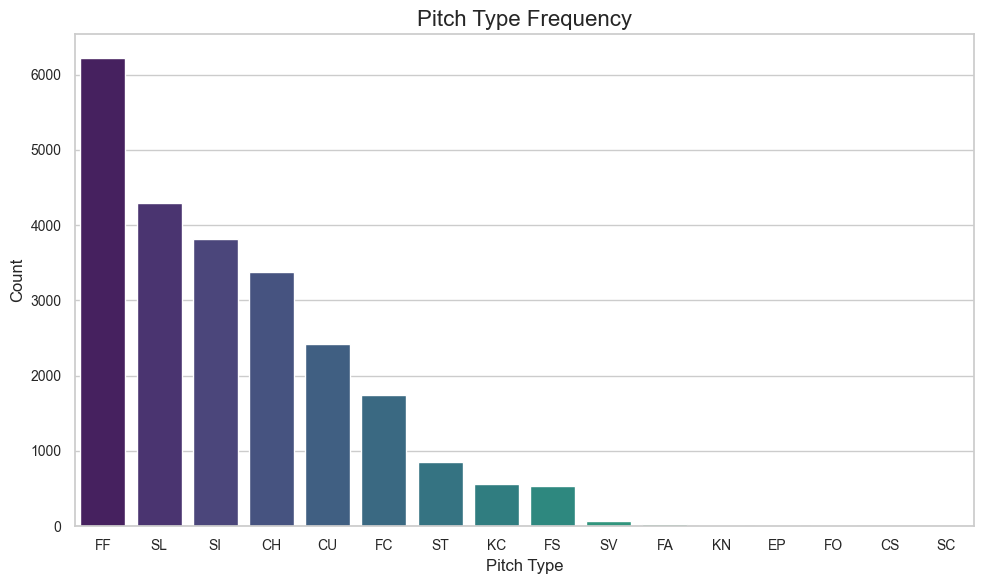

In [7]:
palette = sns.color_palette("viridis", n_colors=df['pitch_type'].nunique())
sns.countplot(data=df, 
            x='pitch_type',
            palette=palette,
            order=df['pitch_type'].value_counts().index
            )

plt.title("Pitch Type Frequency")
plt.xlabel("Pitch Type")
plt.ylabel("Count")
plt.show()

/var/folders/yx/0ffy_sd17hz87_1zrgxmmzbm0000gn/T/ipykernel_25588/3908231624.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette="viridis")


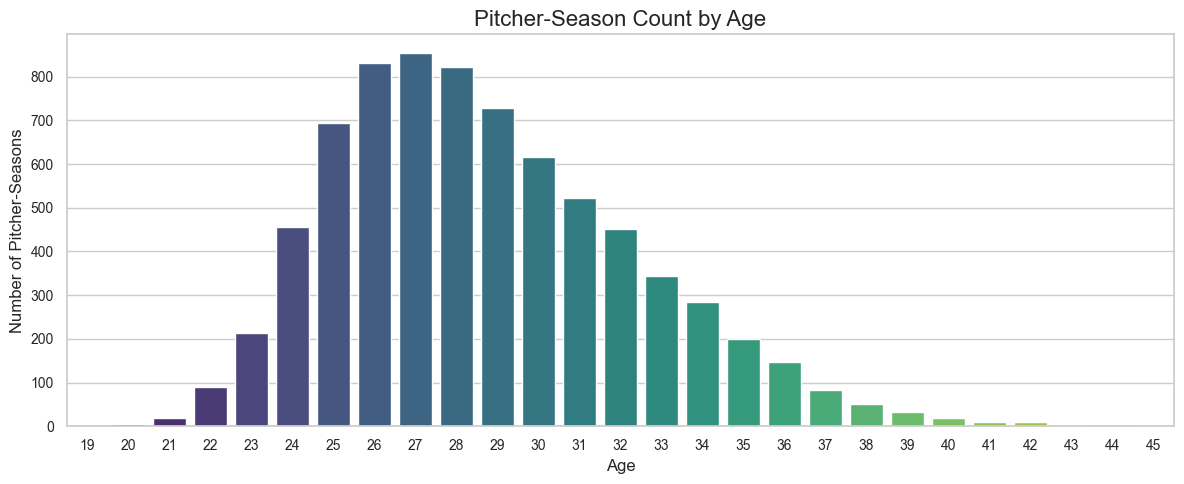

In [8]:
seasons = df.drop_duplicates(subset=["pitcher", "year"])
age_counts = seasons["age"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=age_counts.index, y=age_counts.values, palette="viridis")
plt.title("Pitcher-Season Count by Age")
plt.xlabel("Age")
plt.ylabel("Number of Pitcher-Seasons")
plt.show()

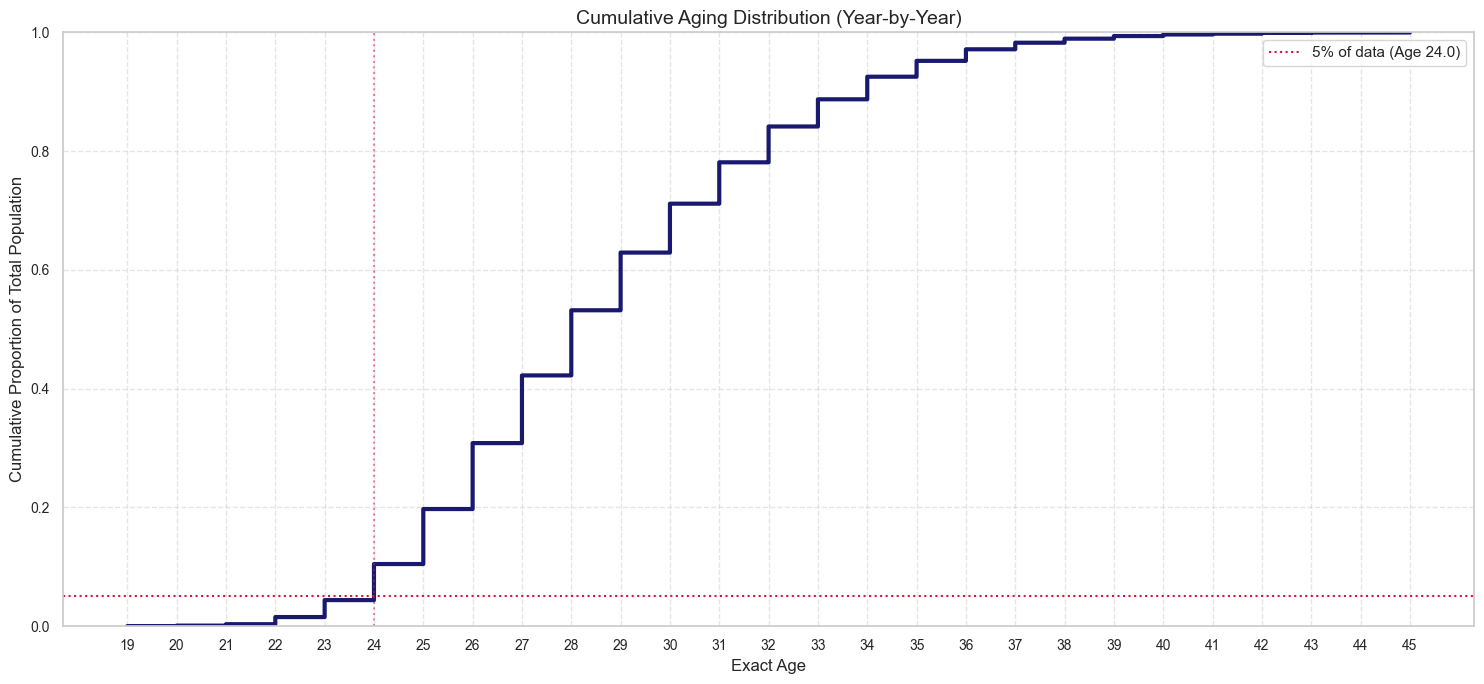

In [9]:
plt.figure(figsize=(15, 7))

sns.ecdfplot(data=seasons, x="age", color="midnightblue", linewidth=3)

min_age = int(seasons["age"].min())
max_age = int(seasons["age"].max())
plt.xticks(np.arange(min_age, max_age + 1, 1))

plt.grid(visible=True, which='both', linestyle='--', alpha=0.5)

p5_age = seasons["age"].quantile(0.05)
plt.axhline(0.05, color='crimson', linestyle=':', label=f'5% of data (Age {p5_age:.1f})')
plt.axvline(p5_age, color='crimson', linestyle=':', alpha=0.5)

plt.title("Cumulative Aging Distribution (Year-by-Year)", fontsize=14)
plt.xlabel("Exact Age", fontsize=12)
plt.ylabel("Cumulative Proportion of Total Population", fontsize=12)
plt.legend()

plt.show()

/var/folders/yx/0ffy_sd17hz87_1zrgxmmzbm0000gn/T/ipykernel_25588/3086169996.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, palette='magma')


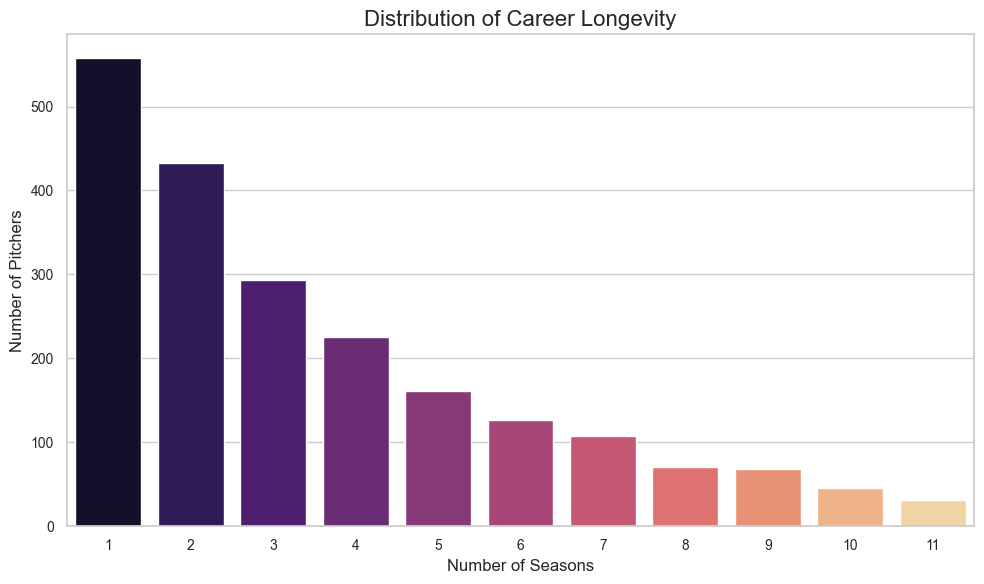

In [10]:
seasons = df.drop_duplicates(subset=["pitcher", "year"])
season_counts = seasons.groupby("pitcher")["year"].count().reset_index()
season_counts.columns = ["pitcher", "num_seasons"]
plot_data = season_counts["num_seasons"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=plot_data.index, y=plot_data.values, palette='magma')

plt.title("Distribution of Career Longevity")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of Pitchers")
plt.show()

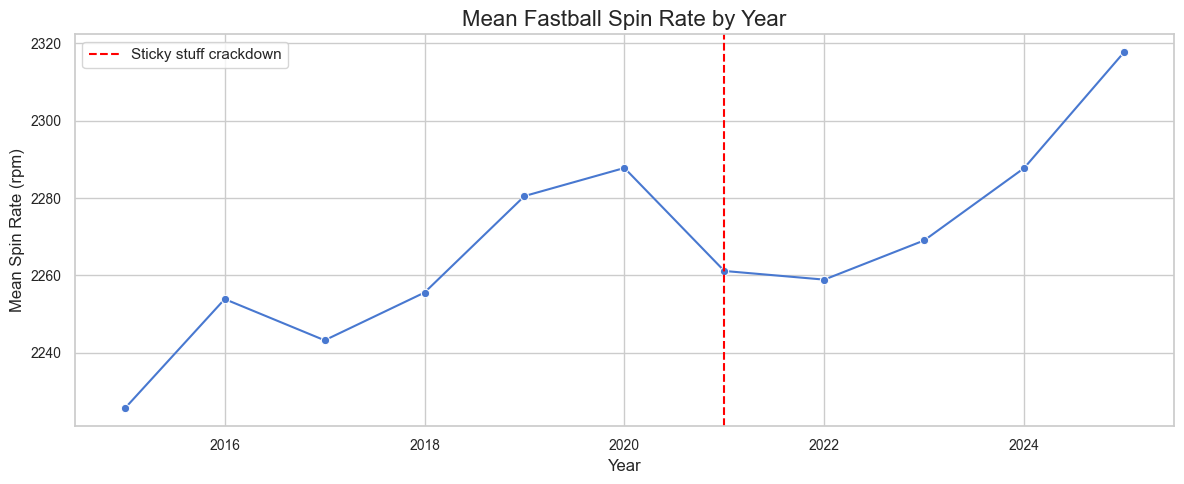

In [11]:
spin_by_year = df[df["pitch_type"] == "FF"].groupby("year")["mean_spin_rate"].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=spin_by_year.index, y=spin_by_year.values, marker="o")
plt.axvline(x=2021, color="red", linestyle="--", label="Sticky stuff crackdown")
plt.title("Mean Fastball Spin Rate by Year")
plt.xlabel("Year")
plt.ylabel("Mean Spin Rate (rpm)")
plt.legend()
plt.show()

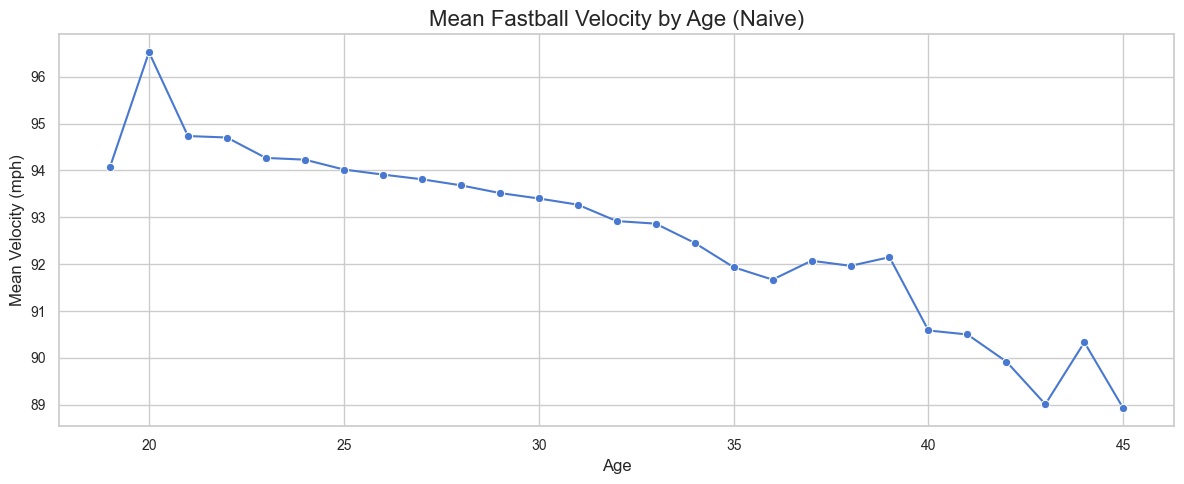

In [12]:
ff = df[df["pitch_type"] == "FF"]
age_velo = ff.groupby("age")["mean_velo"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=age_velo, x="age", y="mean_velo", marker="o")
plt.title("Mean Fastball Velocity by Age (Naive)")
plt.xlabel("Age")
plt.ylabel("Mean Velocity (mph)")
plt.show()

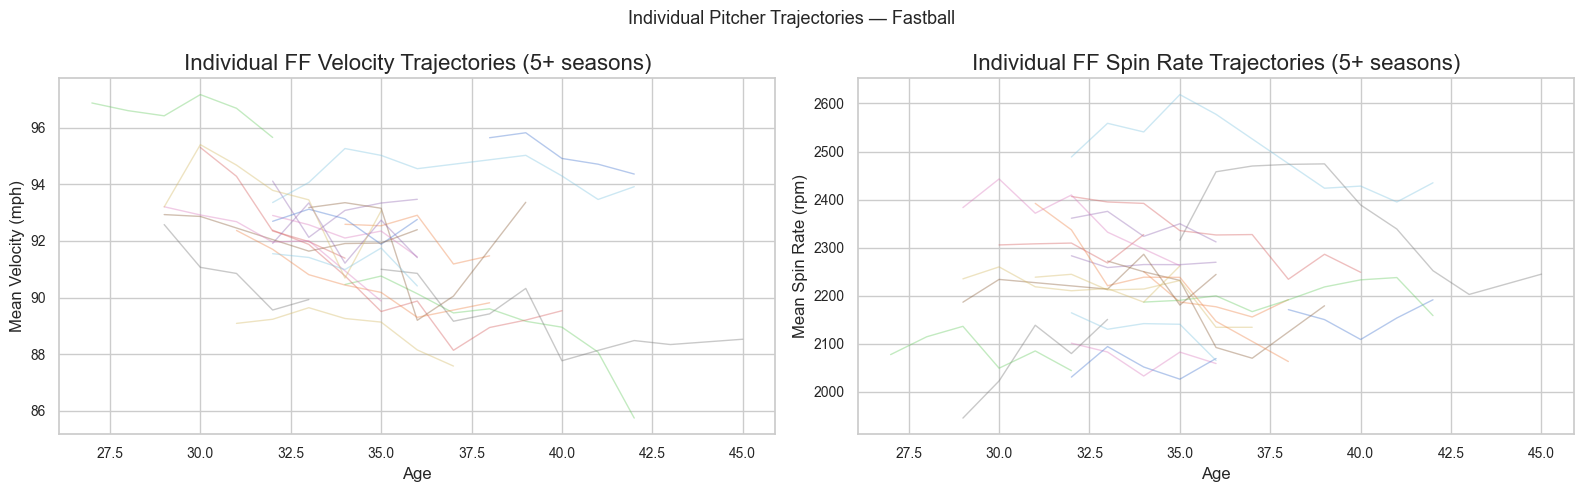

In [13]:
# Only analyzing bigger pitch types for now 
VALID_PITCH_TYPES = ["FF", "SL", "SI", "CH", "CU", "FC"]
df = df[df["pitch_type"].isin(VALID_PITCH_TYPES)]
sample_pitchers = (
    df[df["pitch_type"] == "FF"]
    .groupby("pitcher")
    .filter(lambda x: len(x) >= 5)["pitcher"]
    .unique()[:20]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for pid in sample_pitchers:
    p = df[(df["pitcher"] == pid) & (df["pitch_type"] == "FF")].sort_values("age")
    axes[0].plot(p["age"], p["mean_velo"], alpha=0.4, linewidth=1)
axes[0].set_title("Individual FF Velocity Trajectories (5+ seasons)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Mean Velocity (mph)")


for pid in sample_pitchers:
    p = df[(df["pitcher"] == pid) & (df["pitch_type"] == "FF")].sort_values("age")
    axes[1].plot(p["age"], p["mean_spin_rate"], alpha=0.4, linewidth=1)
axes[1].set_title("Individual FF Spin Rate Trajectories (5+ seasons)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Mean Spin Rate (rpm)")

plt.suptitle("Individual Pitcher Trajectories — Fastball", fontsize=13)
plt.tight_layout()
plt.show()


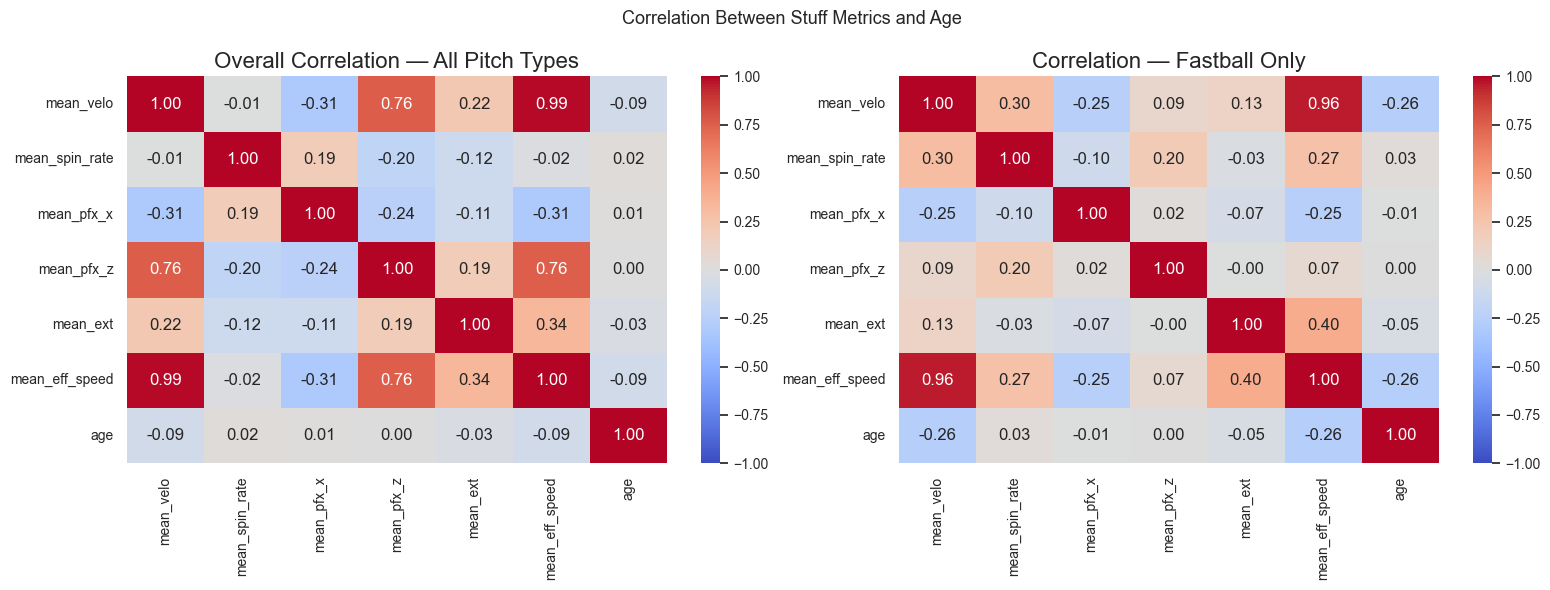

In [14]:
corr_cols = [
    "mean_velo", "mean_spin_rate", "mean_pfx_x",
    "mean_pfx_z", "mean_ext", "mean_eff_speed", "age"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, ax=axes[0]
)
axes[0].set_title("Overall Correlation — All Pitch Types")

sns.heatmap(
    df[df["pitch_type"] == "FF"][corr_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1, ax=axes[1]
)
axes[1].set_title("Correlation — Fastball Only")

plt.suptitle("Correlation Between Stuff Metrics and Age", fontsize=13)
plt.tight_layout()
plt.show()

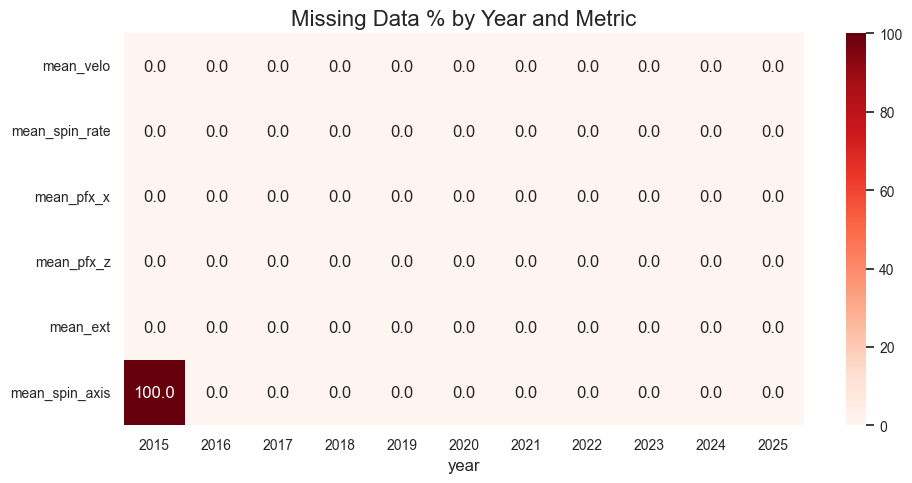

In [15]:
missing_cols = [
    "mean_velo", "mean_spin_rate", "mean_pfx_x",
    "mean_pfx_z", "mean_ext", "mean_spin_axis"
]

missing = (
    df.groupby("year")[missing_cols]
    .apply(lambda x: x.isna().mean() * 100)
)

plt.figure(figsize=(10, 5))
sns.heatmap(missing.T, annot=True, fmt=".1f", cmap="Reds")
plt.title("Missing Data % by Year and Metric")
plt.tight_layout()
plt.show()

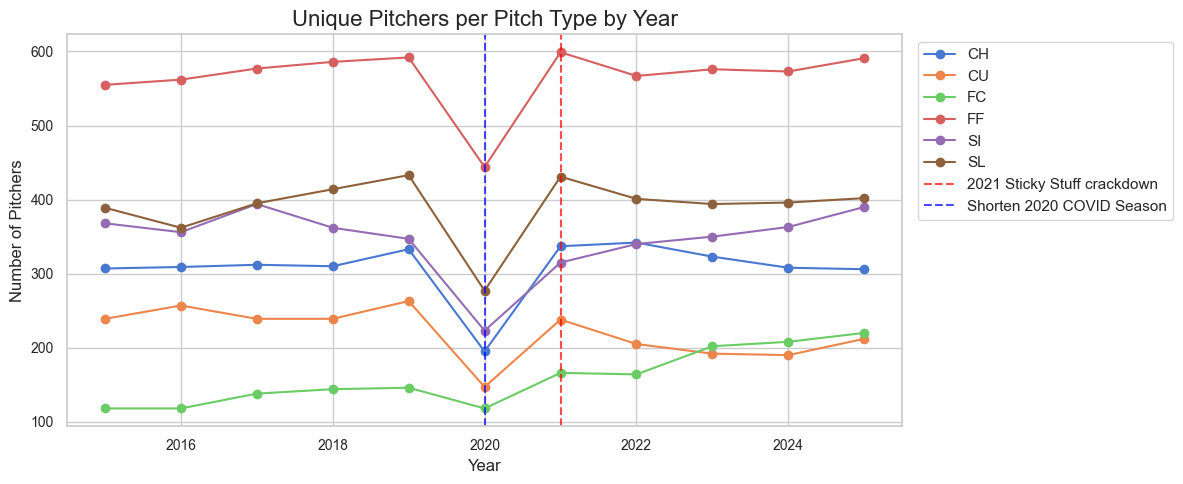

In [16]:
pivot = (
    df.groupby(["year", "pitch_type"])["pitcher"]
    .nunique()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 5))
pivot.plot(ax=plt.gca(), marker="o")
plt.axvline(x=2021, color="red", linestyle="--", alpha=0.7, label="2021 Sticky Stuff crackdown")
plt.axvline(x=2020, color="blue", linestyle="--", alpha=0.7, label="Shorten 2020 COVID Season")
plt.title("Unique Pitchers per Pitch Type by Year")
plt.xlabel("Year")
plt.ylabel("Number of Pitchers")
plt.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

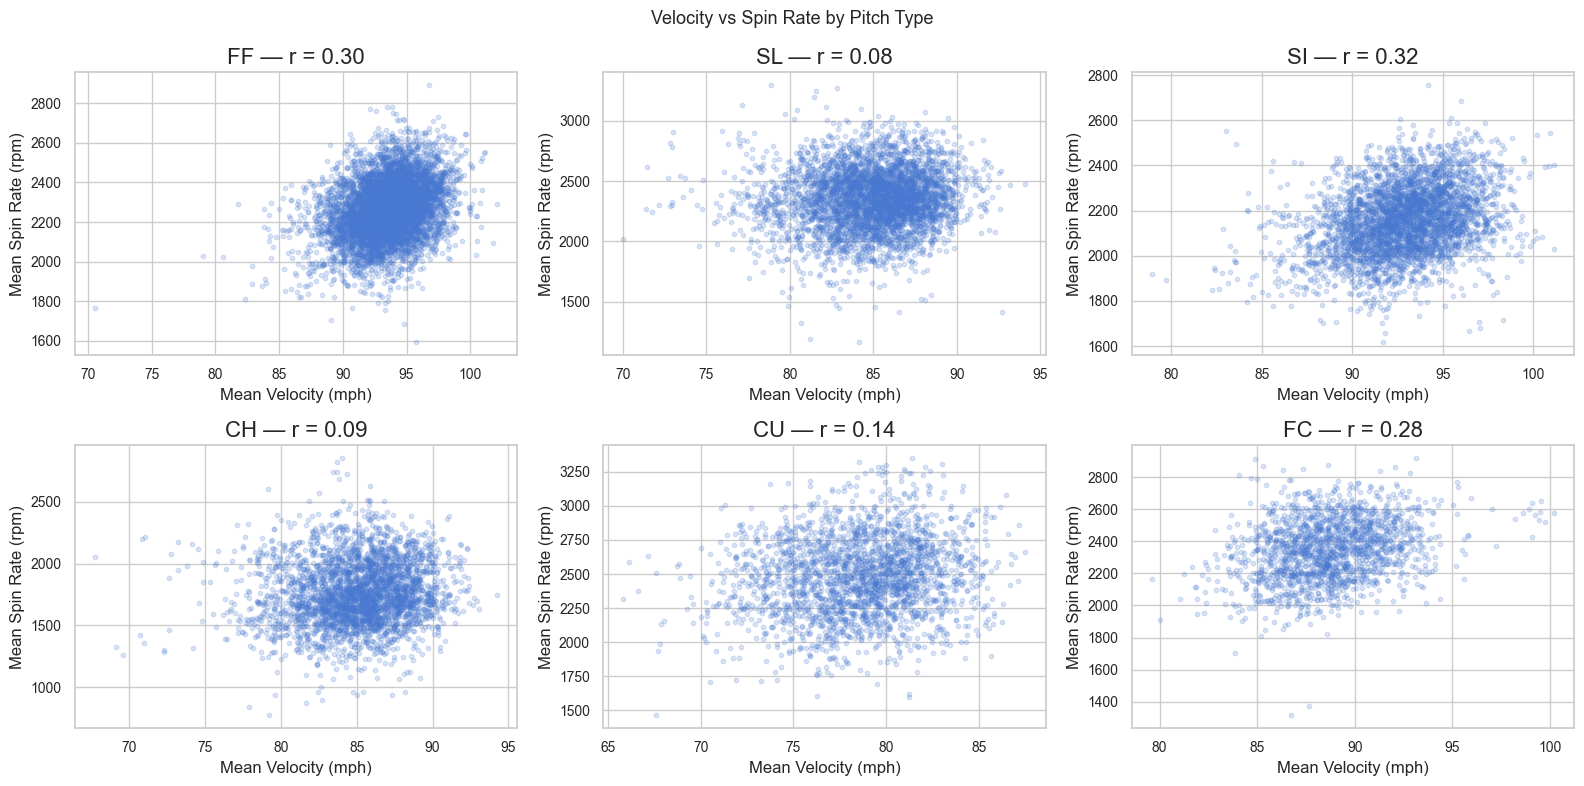

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, pt in zip(axes.flatten(), VALID_PITCH_TYPES):
    pt_df = df[df["pitch_type"] == pt]
    ax.scatter(pt_df["mean_velo"], pt_df["mean_spin_rate"], 
               alpha=0.2, s=10)
    corr = pt_df[["mean_velo", "mean_spin_rate"]].corr().iloc[0, 1]
    ax.set_title(f"{pt} — r = {corr:.2f}")
    ax.set_xlabel("Mean Velocity (mph)")
    ax.set_ylabel("Mean Spin Rate (rpm)")

plt.suptitle("Velocity vs Spin Rate by Pitch Type", fontsize=13)
plt.tight_layout()
plt.show()

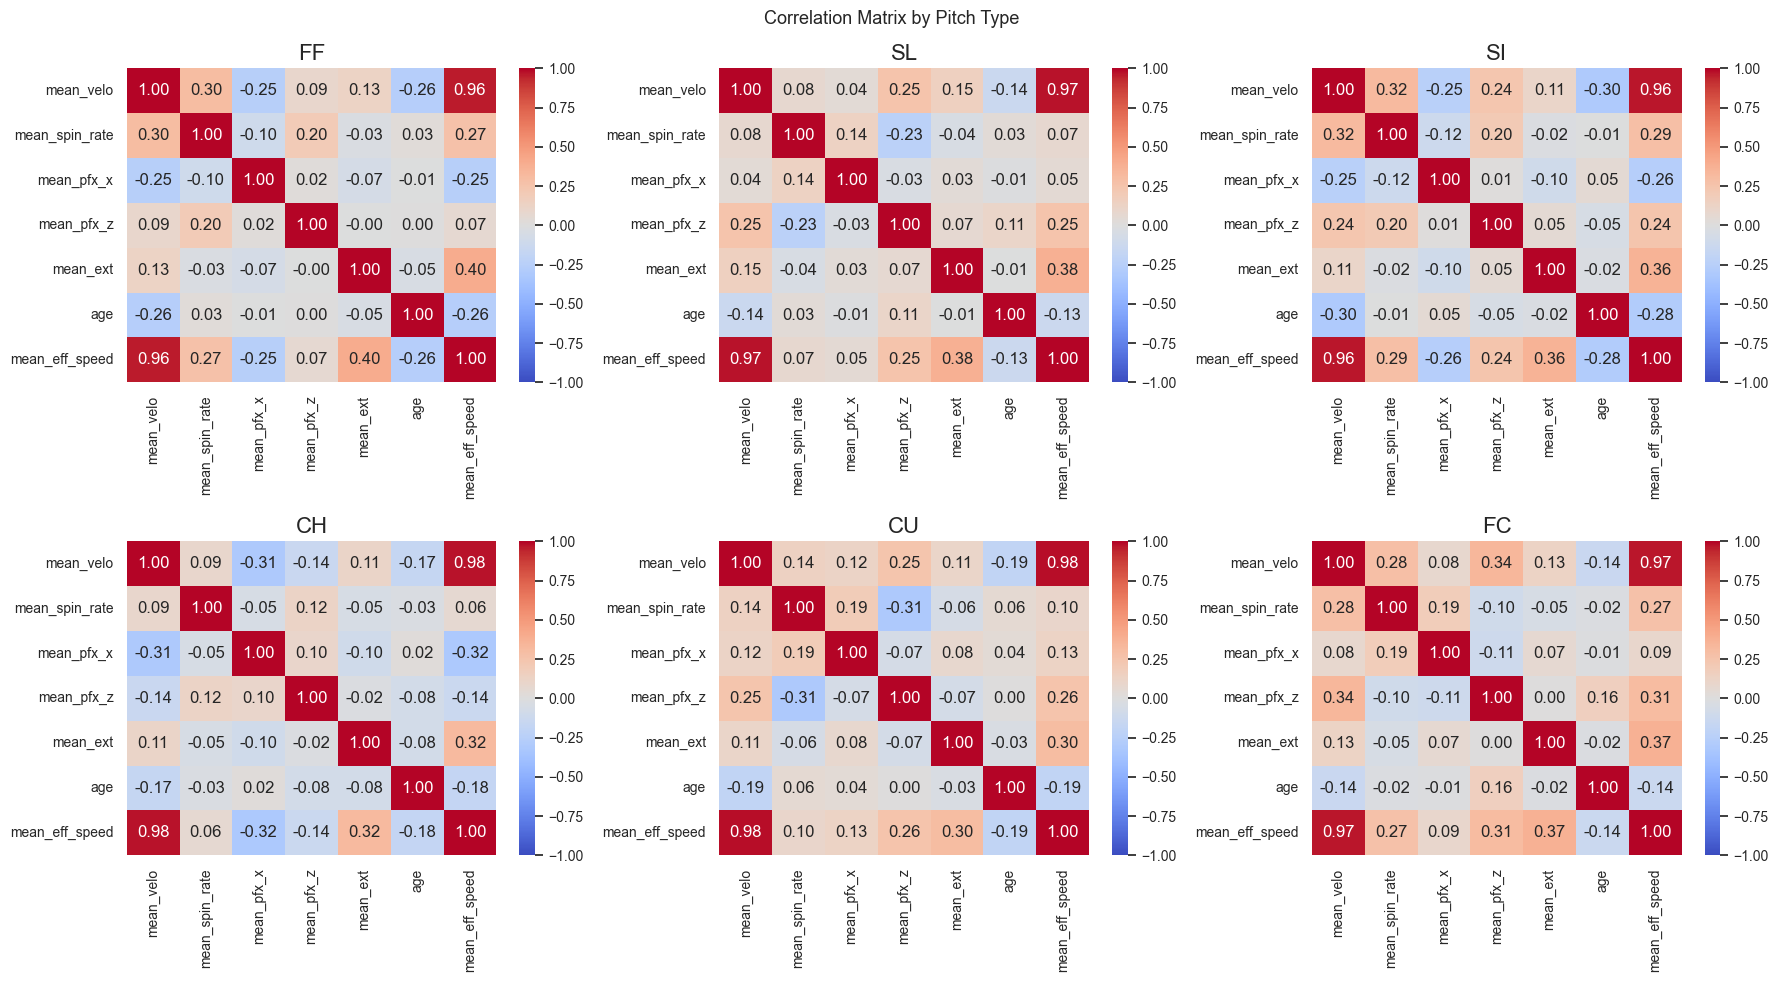

In [18]:
corr_cols = [
    "mean_velo", "mean_spin_rate", "mean_pfx_x",
    "mean_pfx_z", "mean_ext", "age", "mean_eff_speed"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, pt in zip(axes.flatten(), VALID_PITCH_TYPES):
    corr = df[df["pitch_type"] == pt][corr_cols].corr()
    sns.heatmap(
        corr,
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0,
        vmin=-1, vmax=1,
        ax=ax
    )
    ax.set_title(pt)

plt.suptitle("Correlation Matrix by Pitch Type", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
coverage = (
    df.groupby(["pitcher", "pitch_type"])["year"]
    .nunique()
    .reset_index()
    .rename(columns={"year": "n_seasons"})
    .groupby("pitch_type")
    .agg(
        total      = ("pitcher", "count"),
        three_plus = ("n_seasons", lambda x: (x >= 3).sum()),
        five_plus  = ("n_seasons", lambda x: (x >= 5).sum()),
    )
    .assign(
        pct_3plus = lambda x: (100 * x["three_plus"] / x["total"]).round(1),
        pct_5plus = lambda x: (100 * x["five_plus"] / x["total"]).round(1),
    )
    .sort_values("total", ascending=False)
)

print("Pitch Type Coverage:")
print(coverage.to_string())

Pitch Type Coverage:
            total  three_plus  five_plus  pct_3plus  pct_5plus
pitch_type                                                    
FF           1875         928        477       49.5       25.4
SL           1447         651        306       45.0       21.1
SI           1232         572        272       46.4       22.1
CH           1107         488        254       44.1       22.9
CU            849         352        157       41.5       18.5
FC            624         246        112       39.4       17.9


### Checking how many pitchers survive multiple seasons 

In [20]:
total_pitchers = df["pitcher"].nunique()
multi_season = season_counts[season_counts["num_seasons"] >= 3]["pitcher"].nunique()
long_career = season_counts[season_counts["num_seasons"] >= 5]["pitcher"].nunique()

print(f"Total unique pitchers: {total_pitchers}")
print(f"3+ seasons: {multi_season} ({100*multi_season/total_pitchers:.1f}%)")
print(f"5+ seasons: {long_career} ({100*long_career/total_pitchers:.1f}%)")

Total unique pitchers: 2090
3+ seasons: 1128 (54.0%)
5+ seasons: 610 (29.2%)
